# Load Requirements

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%capture
!pip install unsloth
# Also get the latest nightly Unsloth!
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git

In [ ]:
from unsloth import FastLanguageModel

from google.colab import files
from pathlib import Path
import pandas as pd
from datasets import Dataset

from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq, EarlyStoppingCallback
from unsloth import is_bfloat16_supported

from unsloth.chat_templates import train_on_responses_only

from unsloth.chat_templates import get_chat_template
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

!pip install langchain_community
from typing import List, Union
from pydantic import BaseModel, Field, Extra
from langchain.prompts import PromptTemplate
from langchain.schema import AIMessage
from langchain.chains import LLMChain
from langchain.output_parsers import PydanticOutputParser
from langchain.llms import HuggingFacePipeline
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import transformers
import torch
import huggingface_hub
from huggingface_hub import login
from google.colab import userdata

import json

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# Load Llama-3.2-3B-Instruct and QLora PEFT Model

In [5]:
max_seq_length = 6144 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

==((====))==  Unsloth 2024.11.10: Fast Llama patching. Transformers:4.46.2.
   \\   /|    GPU: NVIDIA A100-SXM4-40GB. Max memory: 39.564 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.0. CUDA Toolkit: 12.1. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.28.post3. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 32,
    lora_dropout = 0.1, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 42,
    use_rslora = True,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2024.11.10 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


# Load Data

In [7]:
data_path = Path("/labeled_data_5k_final.xlsx")
df = pd.read_excel(data_path.as_posix())
print(df.shape)
df.head()

(5000, 15)


,snapshot_id,id,title,description,location,tax_terms,source_app,company_name,web_url,company,year,month,day,reformatted,label
0,c7e5ef8c-372b-4e7f-aaad-06fecb156cb8,156e92fe-caac-4f07-bc8a-5b4e236acefd,Lead Data Engineer,**Position: Lead Data Engineer **Location: Atl...,"{id=null, city=Atlanta, state=GA, country=US, ...","[""DIRECT_HIRE"", ""FULL_TIME""]",Email,NaN,https://www.dice.com/job-detail/156e92fe-caac-...,"{id=1395392, company_id=null, name=null, comp_...",2024,4,24,```markdown\n# Lead Data Engineer\n\n## Respon...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
1,b6a8b323-6bf4-45bc-891c-4d9f8de1278f,4b7fe437-491c-4cb0-a79e-e8d07fa26d28,Service Desk Support Specialist,Service Desk Support Specialist - MSP Support ...,"{id=null, city=Dallas, state=TX, country=US, p...","[""DIRECT_HIRE"", ""FULL_TIME""]",Jobman,NaN,https://www.dice.com/job-detail/4b7fe437-491c-...,"{id=68766, company_id=null, name=null, comp_ur...",2024,6,7,```markdown\n# Service Desk Support Specialist...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
2,386dcf65-d21a-4f0f-beee-68cf9aef2358,13215537-4e3c-414c-acb2-84c39517b9fe,Azure DevOps Engineer,Role - AZURE DEVOPS ENGINEERClient - STARBUCKS...,"{id=null, city=Seattle, state=WA, country=US, ...","[""CONTRACT"", ""CONTRACT_W2"", ""CONTRACT_INDEPEND...",Jobman,NaN,https://www.dice.com/job-detail/13215537-4e3c-...,"{id=1543881, company_id=null, name=null, comp_...",2024,9,9,```markdown\n# Azure DevOps Engineer\n\n## Qua...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
3,39c3a478-7874-436a-9d55-42222e116f0b,795948ae-f431-437f-a161-56c92ab3bfb0,Front End Developer withAngular 14or later,Looking for :- Front End DeveloperDuration: 6 ...,"{id=null, city=null, state=null, country=null,...","[""CONTRACT"", ""CONTRACT_W2""]",Jobman,NaN,https://www.dice.com/job-detail/795948ae-f431-...,"{id=1407404, company_id=null, name=null, comp_...",2024,6,6,```markdown\n# Job Title: Front End Developer\...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
4,102071a1-3a2c-4fde-8375-dcb747f9357e,6d69457c-f614-400f-b6f3-7f8ed6c7899c,Active Directory Consultant,Job DescriptionSNI Technology Active Directory...,"{id=null, city=Goldsboro, state=PA, country=US...","[""DIRECT_HIRE"", ""FULL_TIME""]",Aspen,NaN,https://www.dice.com/job-detail/6d69457c-f614-...,"{id=1739786, company_id=null, name=null, comp_...",2024,6,13,```markdown\n# Job Title: Active Directory Con...,"{""Required"":{""Education"":[],""Experience"":[{""in..."


In [ ]:
# Check Nulls
null_counts = df.isnull().sum()
print(null_counts)

snapshot_id        0
id                 0
title              0
description        0
location           0
tax_terms          0
source_app         8
company_name    4624
web_url            0
company            0
year               0
month              0
day                0
reformatted        0
label              0
dtype: int64


In [ ]:
# If running for reformatted experiments, selected "reformatted" column. If running for non-reformatted experiments, select "description".
labeled_df = df[["id","reformatted", "label"]]
print(labeled_df.shape)
labeled_df.head()

(5000, 3)


,id,reformatted,label
0,156e92fe-caac-4f07-bc8a-5b4e236acefd,```markdown\n# Lead Data Engineer\n\n## Respon...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
1,4b7fe437-491c-4cb0-a79e-e8d07fa26d28,```markdown\n# Service Desk Support Specialist...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
2,13215537-4e3c-414c-acb2-84c39517b9fe,```markdown\n# Azure DevOps Engineer\n\n## Qua...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
3,795948ae-f431-437f-a161-56c92ab3bfb0,```markdown\n# Job Title: Front End Developer\...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
4,6d69457c-f614-400f-b6f3-7f8ed6c7899c,```markdown\n# Job Title: Active Directory Con...,"{""Required"":{""Education"":[],""Experience"":[{""in..."


In [10]:
print(labeled_df['label'])

0       {"Required":{"Education":[],"Experience":[{"in...
1       {"Required":{"Education":[],"Experience":[{"in...
2       {"Required":{"Education":[],"Experience":[{"in...
3       {"Required":{"Education":[],"Experience":[{"in...
4       {"Required":{"Education":[],"Experience":[{"in...
                              ...                        
4995    {"Required":{"Education":[{"field_of_study":["...
4996    {"Required":{"Education":[],"Experience":[{"in...
4997    {"Required":{"Education":[],"Experience":[{"in...
4998    {"Required":{"Education":[{"field_of_study":[]...
4999    {"Required":{"Education":[{"field_of_study":["...
Name: label, Length: 5000, dtype: object


# Train, Validation, Test Set Split

In [ ]:
# Create train, validation, test split
train_df, test_df_temp = train_test_split(labeled_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_df_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 3500
Validation size: 750
Test size: 750


In [12]:
extraction_prompt = "You are a tool used to extract the requirements and responsibilities from a job description. I will be inputting a series of job descriptions, so please use the following prompt:\n\nFirst, extract the technical skill requirements and responsibilities from the job description as JSON by following these steps:\nStep 1 - Technical skills should be defined as: specific abilities that relate to the use of tools, technologies, programming languages, software applications, or technical processes.\nStep 2 - Extract the technical skills that are explicitly stated in the job description. You must not include soft skills or job titles. You must include any technical skills that are listed as an experience requirement.\nStep 3 - Store each of the technical skills in a key called 'skill_name' under an object called “technical_skills”.\nStep 4 - If multiple technical skills in a phrase are grouped using parentheses or listed using grouping connectors similar to \"including\", \"like\", \"/\", \"or\", or \"such as\" then list the skills in one array so that they result in a single skill_name. If technical skills are listed without grouping connectors and in a phrase ending in \"and\" then treat each listed skill as a separate skill_name. When skills are listed with no clear grouping implied, list each skill individually rather than in an array.  Below are examples of desired outputs:\nExample phrase 1 -  \"experience of 6+ years using cybersecurity architectures, IDS/IPS, SIEM tools, or firewalls\"\nExample output 1 - skill_name: [cybersecurity architectures, IDS/IPS, SIEM tools, firewalls]\nExample phrase 2 - \"knowledge of database systems including MySQL, PostgreSQL, and Redis\" \nExample output 2 - skill_name: [database systems, MySQL, PostgreSQL, Redis]\nExample phrase 3  - \"4+ years experience with Java/JEE, SOAP/REST/Micro Services, XML\"\nExample output 3 (3 separate skill_name keys) - skill_name: [Java, JEE], skill_name: [SOAP, REST, Micro Services], skill_name: [XML] \nExample phrase 4  - \"experience with SQL Server, Oracle, MongoDB\" \nExample output 4 (3 separate skill_name keys) - skill_name: [SQL Server], skill_name: [Oracle], skill_name: [MongoDB]\nExample phrase 5 -  \"4 or more years experience with messaging architectures (EAI), SAP XI, BizTalk, and Web Services\" \nExample output 5 (4 separate skill_name keys) - skill_name: [messaging architectures, EAI], skill_name: [SAP XI], skill_name: [BizTalk], skill_name: [Web Services]\nExample phrase 6 - \"AWS Knowledge: Event Bridge, Cloud Watch, Cloud Trail\"\nExample output 6 (4 separate skill_name keys) - skill_name: [AWS], skill_name: [Event Bridge], skill_name: [Cloud Watch], skill_name: [Cloud Trail],\nExample phrase 7 - \"Working knowledge of EDB, Oracle, and AWS operations (S3, EC2).\"\nExample output 7 (3 separate skill_name keys) - skill_name: [EDB], skill_name: [Oracle], skill_name: [AWS Operations, S3, EC2]\nExample phrase 8 - \"expertise in the SAP Analytics Roadmap and new technologies such as SAP HANA, and SAP SAC.\"\nExample output 8 (2 separate skill_name keys) - skill_name: [SAP Analytics Roadmap], skill_name: [SAP HANA, SAP SAC]\nExample phrase 9 - \"Demonstrated understanding of WAN, LAN, and VPN networks, including the relationship between network infrastructure and IP-enabled devices.\"\nExample output 9 (4 separate skill_name keys) - skill_name: [WAN], skill_name: [LAN], skill_name: [VPN networks], skill_name: [network infrastructure, IP-enabled devices]\nStep 5 - Classify each of the technical skills that are described as mandatory, essential, needed, or similar as ‘required’. Classify the technical skills that are described as preferred, nice to have, or similar as ‘preferred’. If a requirement is not mentioned or not clear, then classify it as ‘preferred’. If a technical skill is only described under job responsibilities or job duties then classify it as 'preferred'. Separate the skills under two objects called ‘required’ and ‘preferred’.\nStep 6 - For each skill, extract the minimum years required explicitly stated for that specific skill (not inferred or through association) and list 0 if years are not explicitly stated for that specific skill. If a range of years is given, use the smallest year. Label these using a key called ‘minyears’.\nStep 7 - If any two technical skills you have extracted are extremely similar, merge them into a single skill_name array.\n\nNext, extract the required level of education from the job description as JSON by following these steps:\nStep 1 - Locate the requirements, qualifications, prerequisite, or a similar section of the job description and extract any educational requirements that are explicitly stated.\nStep 2 - Create a key called ‘education_level’ that lists the levels of education mentioned in the job qualifications. Categorize the levels of education under one of the following values that fits best: High School Diploma, Associate's, Current Bachelor's Student, Bachelor’s, Current Master's Student, Master’s, Doctorate, Postdoctorate, Vocational, None.\nStep 3 - Classify the levels of education that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the levels of education that are explicitly described as preferred, nice to have, or similar as ‘preferred’.  If a qualification is not mentioned, then classify the level of education as ‘preferred’.  Separate these levels of education under two objects called ‘required’ and ‘preferred’.\nStep 4 - If more than one level of education meets the necessary requirement, classify the higher levels of education as 'preferred'. If multiple levels of education are preferred, store them all as one level of education using an array of comma separated values. As a result, there should only be one 'education_level' key in each of the 'required' and 'preferred' object. For example, phrases like \"A Bachelor's is required, a Master's/PhD is preferred\" would have Bachelor's under the 'required' object but [Master's, Doctorate] under the 'preferred' object.\nStep 5 - If experience is an acceptable alternative to an education requirement, add 'Or Experience' as a value into the 'education_level' array, but only if there is an existing education level. Below are examples of desired outputs:\nExample phrase 1 - \"a Master's degree in mathematics, STEM, or a related field, or 2 years of experience\"\nExample output 1 - education_level: [Master's, Or Experience] \nExample phrase 2- \" graduate in information systems or equivalent hands-on work experience\"\nExample output 2 - education_level: [Bachelor's, Or Experience] \nExample phrase 3 - \"**Option A**: Bachelor's or higher degree with at least 30 semester hours in mathematics and physical sciences.- **Option B**: Combination of education and experience equivalent to a 4-year course of study.\"\nExample output 3- education_level: [Current Bachelor's, Or Experience] \nStep 6 - For each level of education in the list, identify and include any fields of study mentioned in a key called ‘field_of_study’ as separate values in an array. If terms like  \"or similar\", \"or equivalent\", or \"or related\" are used, include ‘Related’ as a field of study. If no fields of study are listed then do not list anything. Below are examples of desired outputs:\nExample phrase 1 - \"A Bachelor's degree in Computer Science, STEM, or a related field\"\nExample output 1 - field_of_study: [Computer Science, STEM, Related]\nExample phrase 2 - \"A graduate in Computer Science, Business, STEM, or equivalent\"\nExample output 2 - field_of_study: [Computer Science, STEM, Related]\n\nNext extract any required credentials, certifications, licenses, or similar credentials from the job description as JSON by following these steps:\nStep 1 - Search within the job description for certifications, licenses, security clearances, or similar credential qualifications that are related to the job. \nStep 2 - Extract the names of any certifications, licenses, security clearances, or similar credentials that are explicitly stated under keys called ‘credential’. Do not include credential qualifications that are not related to the job like driver's licenses, citizenship documentation, or other unrelated credentials.\nStep 3 - If multiple options are acceptable, place them in an array under the credential. If both a credential and it's abbreviation/acronym are given, provide both in the array. Below are examples of desired outputs:\nExample phrase 1 - \"Certified as IAT or IAM Level III\"\nExample output 1- field_of_study:  [IAM Level III Certification, IAT Level III Certification]\nExample phrase 2 - \"CCNP (Cisco Certified Network Professional)\"\nExample output 2 - field_of_study:  [CCNP, Cisco Certified Network Professional]\nStep 4 - Classify each of these credentials that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the credentials that are explicitly described as preferred, nice to have, or similar as ‘preferred’. If a qualification is not mentioned, then classify the credential as ‘preferred’. Separate these credentials under two objects called ‘required’ and ‘preferred’.\nStep 5 - If any certifications, licenses, security clearances, or similar credentials are listed as a technical skill, you must remove them from the technical skill section.\nStep 6 - The output should be structured under the key ‘Credentials’, under objects for ‘required’ and ‘preferred’.\n\nNext, extract the experience requirements from the job description as JSON by following these steps:\nStep 1 - Experience is defined as: The amount and type of prior work experience a candidate must have in order to qualify for the job or to complete the duties of the job. This includes the level of seniority, industry background, job responsibilities, and job duties but does not include technical skills.\nStep 2 - Identify and extract any experience requirements that are explicitly stated in the job description.\nStep 3 - Create a key for each experience requirement under a key called 'experience_desc'. \nStep 4 - Review the experience requirements and if any of them involve technical skills then you must remove them.\nStep 5 - If multiple experiences in a phrase are grouped using parentheses or listed using grouping connectors similar to \"including\", \"like\", \"/\", \"or\", or \"such as\" then you must list the experiences in one array so that they result in a single experience_desc. If experiences are listed without grouping connectors and listed in a phrase ending in \"and\" then you must treat each listed experience as a separate experience_desc. When no clear grouping is implied then you must list each experience individually rather than in an array. Below are examples of desired outputs:\nExample phrase 1 - \"7+ years overall experience in product management, marketing analysis, or professional services\"\nExample output 1 - experience_desc: [product management, marketing analysis, professional services]\nExample phrase 2 - \"must have leadership experience (manager, director, or VP level)\"\nExample output 2 - experience_desc: [manager, director, VP]\nExample phrase 3 - \"3+ years in designing, implementing, and optimizing custom solutions for enterprise software applications\"\nExample output 3 (3 separate experience_desc keys) - experience_desc: [designing custom solutions for enterprise software applications], experience_desc: [implementing custom solutions for enterprise software applications], experience_desc: [optimizing custom solutions for enterprise software applications]\nExample phrase 4 - \"1-2 years of experience leading software teams and working in an agile, kanban, or scrum environment\"\nExample output 4 (2 separate experience_desc keys) - experience_desc: [leading software teams], experience_desc: [agile environment, kanban environment, scrum environment]\nExample phrase 5 - \"professional experience with version/source control, design/application, development principles/methodologies, integration tools\"\nExample output 5 (4 separate experience_desc keys) - experience_desc: [version control, source control], experience_desc: [design, application], experience_desc: [development principles, development methodologies], experience_desc: [integration tools]  \nStep 6 - If terms like \"or similar\", \"or equivalent\", or \"or related\" are used to describe an experience requirement you must include ‘Related’ in the array.  Below are examples of desired outputs:\nExample phrase 1 - \"experience as a data scientist or a related role\"\nExample output 1 - experience_desc: [data scientist, Related]\nExample phrase 2 - \"5+ years of data engineering experience or equivalent\"\nExample output 2 - experience_desc: [data engineering, Related]\nStep 7 - If experience is listed as a requirement without specifying a type of experience, then list the experience as 'Work Experience'. Below are examples of desired outputs:\nExample phrase 1 - \"4+ years of experience are required\"\nExample output 1 - experience_desc: [Work Experience]\nExample phrase 2 - \"Experience Required: 5 years\"\nExample output 2 - experience_desc: [Work Experience]\nStep 8 - Identify the education requirements in the job description. For any phrasing that includes work experience as an alternative to an education requirement, such as \"equivalent experience\", \"equivalent hands-on work experience\", \"relevant experience\", or \"professional experience\" you must include an additional experience_desc key with the values [Work Experience, Or Education]. You must apply this rule to any phrasing where work experience is presented as an acceptable substitute for an education requirement. Below are examples of desired outputs:\nExample phrase 1 - \"An degree in engineering or 3+ years of relevant experience\"\nExample output 1 - experience_desc: [Work Experience, Or Education] \nExample phrase 2 - \"A Bachelor's degree in computer science (or equivalent experience) is needed\" \nExample output 2 - experience_desc: [Work Experience, Or Education] \nExample phrase 3 - \"Master of Science degree in computer science, MIS, or equivalent hands-on work experience\"\nExample output 3 - experience_desc: [Work Experience, Or Education] \nExample phrase 4 - \"A degree from an accredited university preferred, but related experience is also allowed\"\nExample output 4 - experience_desc: [Work Experience, Or Education] \nStep 9 - For each experience_desc in the list, identify and include any industries mentioned in a key called ‘industry’ as separate values in an array. If terms like  \"or similar\", \"or equivalent\", or \"or related\" are used, include ‘Related’ as an industry.  If no industries are listed then do not list anything. Below are examples of desired outputs:\nExample phrase 1 - \"Minimum of 5+ years of experience as a Project Manager / Scrum Master in the AI/ML industry\"\nExample output 1 - industry: [AI Industry, ML Industry]\nExample phrase 2 - \"7 years of data analyst experience in SaaS\"\nExample output 2 - industry: [SaaS]\nExample phrase 3 - \"Proven leadership experience in fintech or a related industry\"\nExample output 3 - industry: [fintech, Related]\nStep 10 - Classify each of the experiences that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the experiences that are explicitly described as preferred, nice to have, or similar as ‘preferred’. If a requirement is not mentioned or not clear, then classify the experience as ‘preferred’. If an experience is only described under job responsibilities or job duties then classify it as 'preferred'. Separate these experiences under two objects called ‘required’ and ‘preferred’.\nStep 11 - Review each experience, and if any experiences contain technical skills within them remove them from the experience requirements and then add them to the technical skills requirements.\nStep 12 - If any industries under 'required' are described as preferred then remove the industry.\nExample phrase 1 - \"2+ years of experience in Information Technology, preferably in the semiconductor industry\"\nExample output 1 - industry: []\nExample phrase 2 - \"4 years of experience as a data engineer are required, within the finance industry preferred\"\nExample output 2 - industry: []\nStep 13 - For each experience, list the minimum years of experience that is explicitly specified for that experience and list 0 if years are not explicitly specified. If a range of years is given, give the smallest year. Label these using a key called ‘minyears’.\n\nLastly, clean and organize the extracted requirements and responsibilities by following these steps:\nStep 1 - If the job description contains the requirements for multiple positions or multiple levels of a position, you must only keep the 'required' qualifications that are relevant to the lowest position or most entry level position and then treat the rest of the qualifications as 'preferred'.\nStep 2 - Combine the JSON outputs from skills, education, credentials, and experience into one JSON. \nStep 3 - Organize the data under two main objects: 'required' and 'preferred', moving the respective skills, education, credentials, and experience under them accordingly. \nStep 4 - Output the combined JSON."

# Create Datasets

In [ ]:
# This function changes slightly depending on whether or not it is a reformatted or non-reformatted experiment.
def format_chat_template(row):

    row_json = [{"role": "system", "content": extraction_prompt },
               {"role": "user", "content": row["reformatted"]}, # this access of the row changes to row['description'] when running a non-reformated experiment
               {"role": "assistant", "content": row["label"]}]

    row["text"] = tokenizer.apply_chat_template(row_json, tokenize=False)
    return row

In [ ]:
#Create Training Dataset
train_dataset = Dataset.from_pandas(train_df)

train_dataset = train_dataset.map(
    format_chat_template,
    num_proc= 4,
)

Map (num_proc=4):   0%|          | 0/3500 [00:00<?, ? examples/s]

In [ ]:
#Create Validation Dataset
val_dataset = Dataset.from_pandas(val_df)

val_dataset = val_dataset.map(
    format_chat_template,
    num_proc= 4,
)

Map (num_proc=4):   0%|          | 0/750 [00:00<?, ? examples/s]

In [ ]:
#Create Test Dataset
test_dataset = Dataset.from_pandas(test_df)

test_dataset = test_dataset.map(
    format_chat_template,
    num_proc= 4,
)

In [15]:
train_dataset['label'][1]

'{"Required":{"Education":[{"field_of_study":["Computer Science","Related"],"education_level":["Bachelor\'s","Or Experience"]}],"Experience":[{"industry":[],"minyears":[3],"experience_desc":["security engineer"]}],"Credentials":[{"credential":["IAT Level II Certification","Security+ CE Certification"]},{"credential":["Interim Secret level security clearance","Secret level security clearance"]}],"Technical_skills":[]},"Preferred":{"Education":[],"Experience":[{"industry":[],"minyears":[0],"experience_desc":["classified computer facility operational procedures","NISPOM","DSS","RMF","DOD security regimes"]},{"industry":[],"minyears":[0],"experience_desc":["Tenable security center","Nessus","ACAS","Splunk"]},{"industry":[],"minyears":[0],"experience_desc":["heterogeneous Windows and Linux environments","data center operations","infrastructure","systems monitoring","computer clusters of 100+ computers"]},{"industry":[],"minyears":[0],"experience_desc":["documenting systems and operational p

In [16]:
train_dataset[10]['text']

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 03 Dec 2024\n\nYou are a tool used to extract the requirements and responsibilities from a job description. I will be inputting a series of job descriptions, so please use the following prompt:\n\nFirst, extract the technical skill requirements and responsibilities from the job description as JSON by following these steps:\nStep 1 - Technical skills should be defined as: specific abilities that relate to the use of tools, technologies, programming languages, software applications, or technical processes.\nStep 2 - Extract the technical skills that are explicitly stated in the job description. You must not include soft skills or job titles. You must include any technical skills that are listed as an experience requirement.\nStep 3 - Store each of the technical skills in a key called \'skill_name\' under an object called “technical_skills”.\nStep 4 - If multiple technical sk

# Train QLora Finetuned Model

In [ ]:
# Train the model
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset= val_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False, 
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 8,
        warmup_steps = 5,
        num_train_epochs = 5, 
        learning_rate = 2e-5,  # set learning rate here
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,

        evaluation_strategy="steps",  # Evaluate during training at regular intervals
        eval_steps=10,               # Perform evaluation every 10 steps
        save_strategy="steps",       # Save checkpoints at every evaluation
        save_steps=10,               # Same as eval_steps for simplicity
        save_total_limit=2,          # Retain only 2 checkpoints
        load_best_model_at_end=True, # Automatically load the best model after training
        metric_for_best_model="eval_loss",  # Use validation loss to determine the best model
        greater_is_better=False,     # Lower validation loss is better


        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 42,
        output_dir = "outputs",
        report_to = "none", 
    ),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Map (num_proc=2):   0%|          | 0/3500 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/750 [00:00<?, ? examples/s]

We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs.

In [18]:
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

We verify masking is actually done:

In [19]:
tokenizer.decode(trainer.train_dataset[5]["input_ids"])

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 03 Dec 2024\n\nYou are a tool used to extract the requirements and responsibilities from a job description. I will be inputting a series of job descriptions, so please use the following prompt:\n\nFirst, extract the technical skill requirements and responsibilities from the job description as JSON by following these steps:\nStep 1 - Technical skills should be defined as: specific abilities that relate to the use of tools, technologies, programming languages, software applications, or technical processes.\nStep 2 - Extract the technical skills that are explicitly stated in the job description. You must not include soft skills or job titles. You must include any technical skills that are listed as an experience requirement.\nStep 3 - Store each of the technical skills in a key called\'skill_name\' under an object called “technical_skills”.\nStep 4 - If multiple technical ski

In [20]:
space = tokenizer(" ", add_special_tokens = False).input_ids[0]
tokenizer.decode([space if x == -100 else x for x in trainer.train_dataset[5]["labels"]])

'                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [22]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs = 1
   \\   /|    Num examples = 3,500 | Num Epochs = 5
O^O/ \_/ \    Batch size per device = 2 | Gradient Accumulation steps = 8
\        /    Total batch size = 16 | Total steps = 1,090
 "-____-"     Number of trainable parameters = 24,313,856


Step,Training Loss,Validation Loss
10,0.265700,0.254371
20,0.167100,0.158691
30,0.149100,0.131810
40,0.129900,0.118063
50,0.119400,0.109803
60,0.099900,0.106180
70,0.099800,0.100989
80,0.093100,0.098991
90,0.103800,0.095614
100,0.093500,0.093477


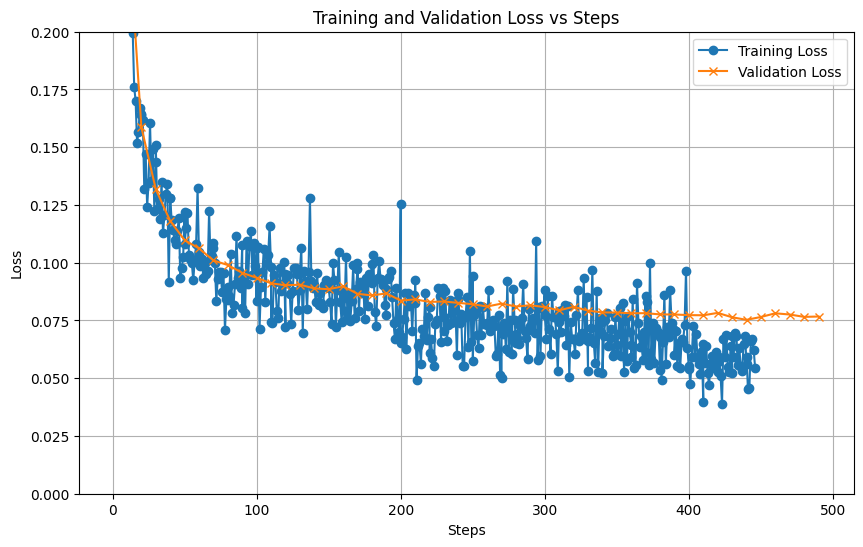

In [23]:
# Extract the loss and step values
log_history = trainer.state.log_history

# Extract training and validation losses
steps = [log["step"] for log in log_history if "step" in log]
training_losses = [log["loss"] for log in log_history if "loss" in log]
validation_steps = [log["step"] for log in log_history if "step" in log and "eval_loss" in log]
validation_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]

# Plot the losses vs steps
plt.figure(figsize=(10, 6))
plt.plot(steps[:len(training_losses)], training_losses, label="Training Loss", marker='o')
if validation_losses:
    plt.plot(validation_steps, validation_losses, label="Validation Loss", marker='x')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Steps")
plt.ylim(0, 0.2)
plt.legend()
plt.grid()
plt.show()


In [24]:
#@title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory         /max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

14625.7855 seconds used for training.
243.76 minutes used for training.
Peak reserved memory = 17.375 GB.
Peak reserved memory for training = 14.74 GB.
Peak reserved memory % of max memory = 43.916 %.
Peak reserved memory for training % of max memory = 37.256 %.


# Save Model Locally

In [ ]:
# Save model to /content directory on google colab
model.save_pretrained("llama_3B_LR2e5_DR01_reformat")
tokenizer.save_pretrained("llama_3B_LR2e5_DR01_reformat")

('llama_3B_LR2e5_DR0_reformat/tokenizer_config.json',
 'llama_3B_LR2e5_DR0_reformat/special_tokens_map.json',
 'llama_3B_LR2e5_DR0_reformat/tokenizer.json')

In [ ]:
# Zip model for downloading to local machine
!zip -r llama_3B_LR2e5_DR01_reformat.zip llama_3B_LR2e5_DR01_reformat

In [ ]:
# Download model to local machine
files.download("llama_3B_LR2e5_DR01_reformat.zip")

# Use Model for Inference

## Loading Model

In [ ]:
# If loading model
!unzip llama_3B_LR2e5_DR01_reformat.zip

loaded_model, loaded_tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/content/llama_3B_LR2e5_DR01_reformat", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

loaded_tokenizer = get_chat_template(
    tokenizer,
    chat_template="llama-3.1",
)
FastLanguageModel.for_inference(loaded_model)

## Using Pretrained Model Directly after QLora PEFT

In [ ]:
# Configure the tokenizer with the chat template
tokenizer = get_chat_template(
    tokenizer,
    chat_template="llama-3.1",
)
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 3072, padding_idx=128004)
        (layers): ModuleList(
          (0-27): 28 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
        

In [17]:
# Modify the generate_output function to return a single string.
def generate_output(description):
    # Assume that extraction_prompt, tokenizer, and model are defined globally
    messages = [
        {"role": "system", "content": extraction_prompt},
        {"role": "user", "content": description},
    ]

    # Tokenize the input with the chat template
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,  # Must add for generation
        return_tensors="pt",
    ).to("cuda")

    # Generate outputs with the model
    outputs = model.generate(
        input_ids=inputs,
        max_new_tokens=2560,
        use_cache=True,
        temperature=1,
        min_p=0.1,
        early_stopping=True
    )

    # Extract the generated portion of the output by slicing
    generated_tokens = outputs[:, inputs.shape[1]:]  # Exclude the input tokens

    # Decode the generated portion into readable text
    decoded_output = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=True  # Exclude special tokens like <pad> or <eos>
    )

    # Return the first generated output as a string
    return decoded_output[0]



# Generating Validation Data Inference Results

In [ ]:
# Apply the generate_output function to each row in validation dataframe
val_df['unstructured_preds'] = val_df['reformatted'].apply(generate_output)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
# Save Predictions
val_df.to_excel('llama_3B_LR2e5_DR01_reformat_preds_raw.xlsx', index=False)  # Remember to rename and download locally

In [ ]:
files.download('llama_3B_LR2e5_DR01_reformat_preds_raw.xlsx')

# Generating Final Test Data Inference Results

In [ ]:
# Apply the generate_output function to each row in test dataframe
test_df['unstructured_preds'] = test_df['reformatted'].apply(generate_output)

In [ ]:
# Save Predictions
val_df.to_excel('best_model_predictions.xlsx', index=False)  # Remember to rename and download locally

In [ ]:
files.download('best_model_predictions.xlsx')